In [70]:
import os
import torch
from gsplat import rasterization
import matplotlib.pyplot as plt
import sys
sys.path.append('../..')  # Adjust the path as necessary to locate the gsplat root directory
from mine.loader import initialize_model_from_ply_file
from examples.datasets.blender_nerf_synthetic import Parser, Dataset

from optical.surface import WaterSruface
from optical.quartic_solver.feralli import solve_quartic_ferrari
from optical.quartic_solver.newton_method import solve_quartic_newton

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'
# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2

device = torch.device("cuda:0")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[autoreload of optical.surface failed: Traceback (most recent call last):
  File "/home/taiki/try-papers/gsplat/venv/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/home/taiki/try-papers/gsplat/venv/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "/home/taiki/try-papers/gsplat/venv/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/home/taiki/try-papers/gsplat/venv/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 349, in update_class
    if update_generic(old_obj, new_obj):
  File "/home/taiki/try-papers/gsplat/venv/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/home/taiki/try-papers/gsplat/venv/lib/python3.10/site-packages/IPython/extensions/autoreload.py", l

In [71]:
# Choose dataset by flag or name
dataset_flag = "river2"  # Change this flag to "river1" or "river2" as needed
home_dir = os.path.expanduser("~")

if dataset_flag == "river1":
    wo_refraction_dataset_path = os.path.abspath(os.path.join(home_dir, "dataset/river_with-refraction"))
    with_refraction_dataset_path = os.path.abspath(os.path.join(home_dir, "dataset/river_wo-refraction"))
    non_refraction_model_path = os.path.abspath("../../../results/favo/river_wo-refraction/ply/point_cloud_29999.ply")
elif dataset_flag == "river2":
    wo_refraction_dataset_path = os.path.abspath(os.path.join(home_dir, "dataset/river2/wo_refraction"))
    with_refraction_dataset_path = os.path.abspath(os.path.join(home_dir, "dataset/river2/refraction"))
    non_refraction_model_path = os.path.abspath("../../../results/river2/2025-0411_13-31_refraction_GT/ply/point_cloud_29999.ply")
else:
    raise ValueError(f"Unknown dataset flag: {dataset_flag}")

# Load the dataset
parser_ref = Parser(
    data_dir=wo_refraction_dataset_path,
)
dataset_ref = Dataset(
    parser_ref,
    split="train",
)

dataloader_ref = torch.utils.data.DataLoader(
    dataset_ref,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    pin_memory=True,
)

Loading 3D point cloud from: /home/taiki/dataset/river2/wo_refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/wo_refraction.


In [72]:
data = dataloader_ref.dataset[30]

# extract data
camtoworlds = data["camtoworld"].view(1,4,4).to(device)  # [1, 4, 4] 
worldtocam = camtoworlds.inverse()
cam_center = camtoworlds[0, :3, 3].detach().clone()
Ks = data["K"].view(1,3,3).to(device)  # [1, 3, 3]
pixels = data["image"].unsqueeze(0).to(device) / 255.0  # [1, H, W, 3]
image_ids = data["image_id"]
height, width = pixels.shape[1:3]

image_name = "train", f"{image_ids:04d}" + ".png"
print(image_name)

('train', '0030.png')


In [73]:
# get Gaussian model from ply file
gs_model_gt = initialize_model_from_ply_file(non_refraction_model_path, device=device)
# get each parameters as tensor from Gaussian model  torch.from_numpy
means     = gs_model_gt.gaussians["means"]      # shape: [N, 3]
scales    = gs_model_gt.gaussians["scales"]     # shape: [N, 3]
quats     = gs_model_gt.gaussians["rotations"]  # shape: [N, 4]
opacities = gs_model_gt.gaussians["opacities"].squeeze(-1)   # shape: (N,)
colors    = gs_model_gt.gaussians["shs"]        # shape: [N, 16, 3]

In [79]:
# Setting Refraction Parameters
n = 1.33
plane = 0.0
num_newton_iters = 10
newton_atol = 1e-6

WS = WaterSruface(
    means=means,
    quats=quats,
    cam_center=cam_center,
    n=n,
    plane=plane,
    flag_solve_quartic_by_newton=False,
)

trandformed_means, trandformed_quats = WS.transform_to_appearance()


ValueError: too many values to unpack (expected 2)

In [75]:
# 補正前の Gaussian を用いてレンダリング
rgb_wo_refraction, _, _ = rasterization(
    means,
    quats,
    scales,
    opacities,
    colors,
    worldtocam,  # Notice! Render world to cam matrix 
    Ks,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_wo_refraction = rgb_wo_refraction.squeeze().cpu().detach().numpy()


In [ ]:
# 補正後の Gaussian を用いてレンダリング
rgb_refraction, _, _ = rasterization(
    trandformed_means,
    trandformed_quats,
    scales,
    opacities,
    colors,
    worldtocam,
    Ks,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_refraction = rgb_refraction.squeeze().cpu().detach().numpy()

GT image without refraction: /home/taiki/dataset/river2/wo_refraction/train/0030.png
GT image with refraction: /home/taiki/dataset/river2/refraction/train/0030.png


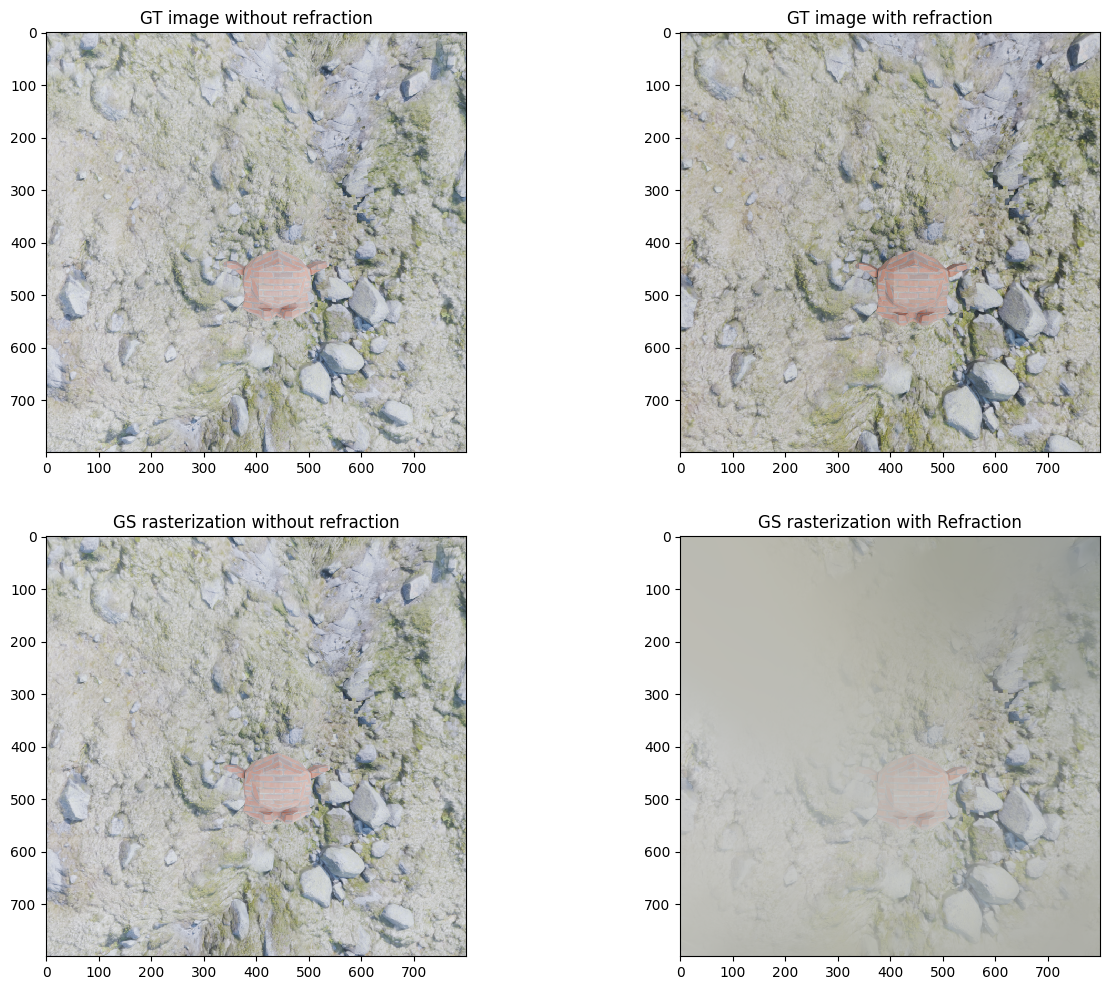

In [77]:
# Display
gt_image_path_wo_ref = os.path.join(wo_refraction_dataset_path, "train", f"{image_ids:04d}" + ".png")
gt_image_wo_ref = plt.imread(gt_image_path_wo_ref)
print(f"GT image without refraction: {gt_image_path_wo_ref}")

gt_image_path_with_ref = os.path.join(with_refraction_dataset_path, "train", f"{image_ids:04d}" + ".png")
gt_image_with_ref = plt.imread(gt_image_path_with_ref)
print(f"GT image with refraction: {gt_image_path_with_ref}")

fig, ax = plt.subplots(2, 2)
ax[0, 0].imshow(gt_image_wo_ref)
ax[0, 0].set_title("GT image without refraction")
ax[0, 1].imshow(gt_image_with_ref)
ax[0, 1].set_title("GT image with refraction")
ax[1, 0].imshow(rgb_wo_refraction)
ax[1, 0].set_title("GS rasterization without refraction")
ax[1, 1].imshow(rgb_refraction)
ax[1, 1].set_title("GS rasterization with Refraction")
plt.show()

# Time Complexity of Algorithms

In [78]:
# import time

# # instantiate two WaterSruface solvers
# RT_ferrari = WaterSruface(
#     means=means,
#     quats=quats,
#     cam_center=cam_center,
#     n=n,
#     plane=plane,
#     flag_solve_quartic_by_newton=False,
# )
# RT_newton = WaterSruface(
#     means=means,
#     quats=quats,
#     cam_center=cam_center,
#     n=n,
#     plane=plane,
#     flag_solve_quartic_by_newton=True,
# )

# # warm up CUDA
# torch.cuda.synchronize()

# # time Ferrari solver
# start = time.time()
# for _ in range(1000):
#     _ = RT_ferrari.transform_to_appearance()
# torch.cuda.synchronize()
# time_ferrari = time.time() - start

# # time Newton solver
# start = time.time()
# for _ in range(1000):
#     _ = RT_newton.transform_to_appearance()
# torch.cuda.synchronize()
# time_newton = time.time() - start

# print(f"Ferrari solver: {time_ferrari:.4f} s for 1000 runs")
# print(f"Newton solver:  {time_newton:.4f} s for 1000 runs")